In [ ]:
# --- Project setup: portable paths (no hard-coded absolute paths) ---
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
ROOT = next(p for p in (_cwd, *_cwd.parents) if (p / "project_paths.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from project_paths import DATA_DIR, MODELS_DIR

In [12]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

# 1. Speicherpfad definieren (muss mit dem Namen beim Speichern übereinstimmen)
model_filename = MODELS_DIR / "best_RF_classifier_SOAP_bandgap.joblib"

# 2. Das Modell laden
try:
    loaded_rf_model = joblib.load(model_filename)
    print(f"Modell erfolgreich geladen aus: {model_filename}")
except FileNotFoundError:
    print(f"Fehler: Die Datei '{model_filename}' wurde nicht gefunden. Überprüfe den Pfad.")

Modell erfolgreich geladen aus: best_RF_classifyer_SOAP_bandgap.joblib


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv(DATA_DIR / "perovskite_metadata_overview_reduced.csv")
print(df_meta.shape)
y = df_meta["is_metal"].values  # Dein Target-Vektor

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load(DATA_DIR / "perovskite_soap_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(8000, 10)
(8000, 48870)
Number of entries:  8000


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [8]:
from sklearn.model_selection import train_test_split

# Angenommen, deine Metadaten liegen in einem Pandas DataFrame oder NumPy Array namens `meta`
# Wichtig: meta.shape[0] muss genau so groß sein wie X.shape[0]

# Du übergibst meta einfach als zusätzliches Argument:
X_train, X_test, y_train, y_test, cs_train, cs_test, bg_train, bg_test, he_train, he_test = train_test_split(
    X, 
    y, 
    df_meta['crystal_structure'], 
    df_meta['band_gap'],
    df_meta['energy_above_hull'],
    test_size=0.2, random_state=42
)

print("X_train Form:", X_train.shape)
print("meta_train Form:", bg_train.shape) # Die Zuordnung bleibt perfekt erhalten!

X_train Form: (6400, 48870)
meta_train Form: (6400,)


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = loaded_rf_model.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
    ))

Model Accuracy: 0.88

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.77      0.88      0.82       488
      Metall (True)       0.94      0.88      0.91      1112

           accuracy                           0.88      1600
          macro avg       0.86      0.88      0.87      1600
       weighted avg       0.89      0.88      0.89      1600



In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model,x_test, y_test, labels_x, labels_y):

    y_pred = model.predict(x_test)

    # 1. Die Confusion Matrix normalisieren ('true' normiert über die tatsächliche Achse)
    cm_percentage = confusion_matrix(y_test, y_pred, normalize="true")

    # 2. Beschriftungen für die Achsen definieren
    #labels_y = ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"]
    #labels_x = ["Kein Metall\n(False)", "Metall\n(True)"]

    # 3. Den Plot erstellen
    plt.figure(figsize=(6, 5))

    # sns.heatmap zeichnet die Matrix
    sns.heatmap(
        cm_percentage,
        annot=True,  # Schreibt die Werte in die Quadrate
        fmt=".1%",  # <--- WICHTIG: Formatiert die Zahlen als Prozent mit einer Nachkommastelle (z.B. 94.5%)
        cmap="Blues",  # Blaue Farbpalette
        xticklabels=labels_x,  # Beschriftung X-Achse
        yticklabels=labels_y,  # Beschriftung Y-Achse
        cbar=True,
        square=True,
        vmin=0,
        vmax=1,  # Setzt die Farbskala fest von 0% bis 100%
    )

    # 4. Titel und Achsenbeschriftungen
    plt.title(
        "Confusion Matrix (Prozentual) - Metall-Klassifikation",
        fontsize=14,
        pad=20,
    )
    plt.xlabel("Vorhersage des Modells (Predicted)", fontsize=12)
    plt.ylabel("Tatsächliche Struktur (Actual)", fontsize=12)

    # Grafik anzeigen
    plt.tight_layout()
    plt.show()

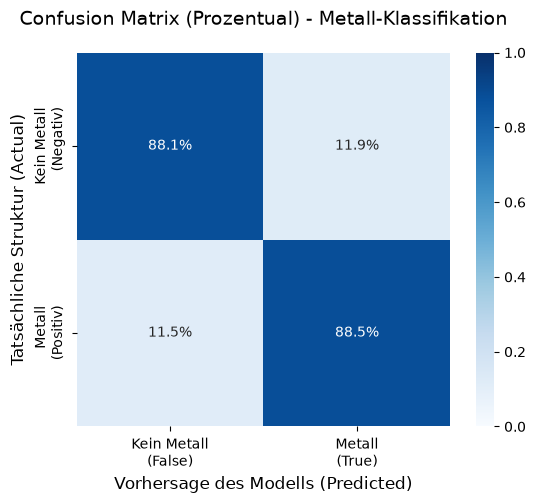

In [14]:
plot_confusion_matrix(loaded_rf_model, X_test, y_test, ["Kein Metall\n(False)", "Metall\n(True)"], ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"])
